# Example-##: Phase advance trig relations

In [1]:
# q(i) = c(i) cos(2 pi nu t) + s(i) sin(2 pi nu t) = a(i) cos(2 pi nu t + b(i))

# a(i) = sqrt(c(i)^2 + s(i)^2)
# b(i) = atan2(-s(i), c(i))

# c(i) = +a(i) cos(b(i))
# s(i) = -a(i) sin(b(i))

# cot(B(j) - B(i)) = (a(i) a(j) + b(i) b(j))/(a(j) b(i) - a(i) b(j))
# sin(B(j) - B(i)) = (a(j) b(i) - a(i) b(j))/(A(i) A(j))
# cos(B(j) - B(i)) = (a(i) a(j) + b(i) b(j))/(A(i) A(j))

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

## Model setup

In [135]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [136]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2**10

In [137]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

In [138]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [139]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [140]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [141]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [142]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [143]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

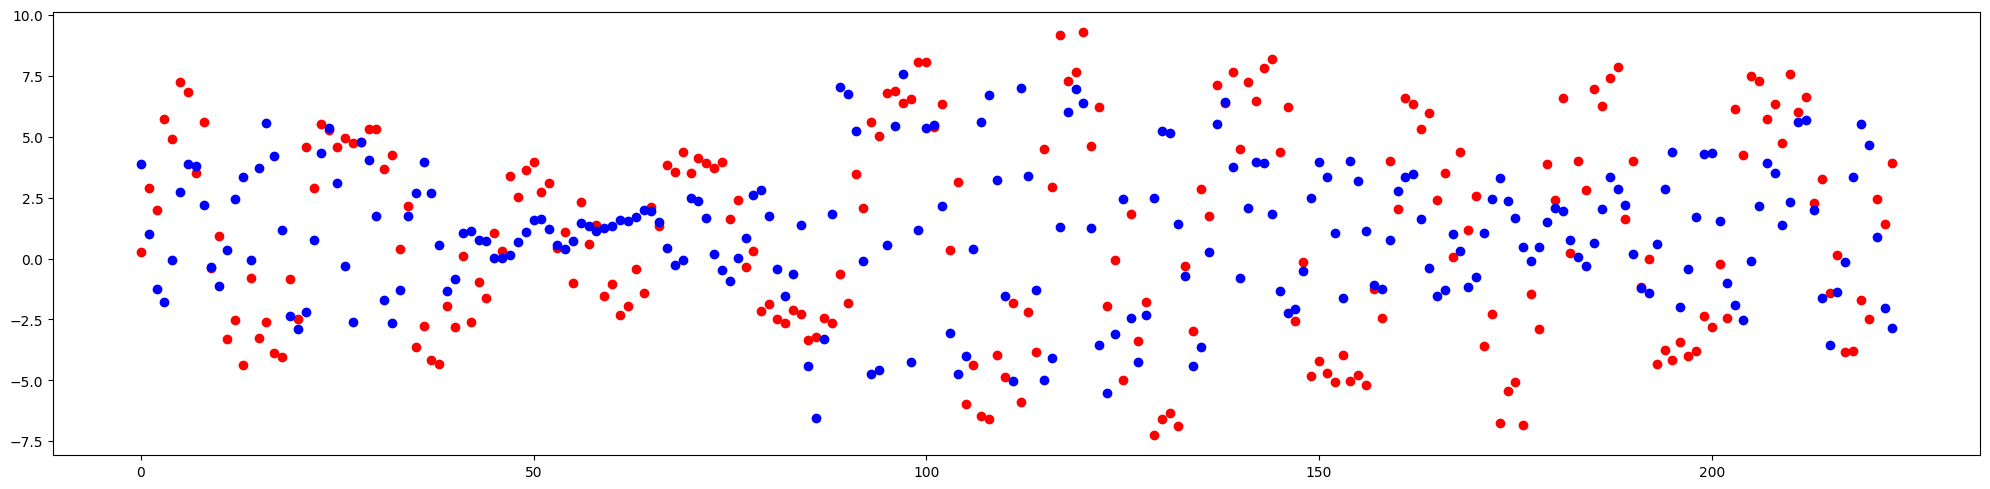

4.33
2.98


In [144]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [145]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

## Harmonic decomposition

In [146]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 1024])
torch.Size([224, 1024])
torch.Size([224, 1024])
torch.Size([224, 1024])


In [164]:
# Set noise

noise_x = 10.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 10.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

In [165]:
# Set data containers

tbt_x.work = qx.clone()
tbt_x.data.copy_(tbt_x.work)
tbt_x.reset()

tbt_y.work = qy.clone()
tbt_y.data.copy_(tbt_y.work)
tbt_y.reset()

In [166]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

print(nux, sigma_nux)
print(nuy, sigma_nuy)

tensor(0.8036, dtype=torch.float64) tensor(4.4745e-10, dtype=torch.float64)
tensor(0.8298, dtype=torch.float64) tensor(3.0752e-10, dtype=torch.float64)


In [167]:
# Compute amplitudes and phases (horizontal and vertical)

axx, sigma_axx, _ = d_x.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, sigma_fxx, _ = d_x.harmonic_phase(nux, length=512, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

ayy, sigma_ayy, _ = d_y.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, sigma_fyy, _ = d_y.harmonic_phase(nuy, length=512, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [168]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              sigma_nux, sigma_nuy,
              sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
              dtype=dtype,
              device=device)

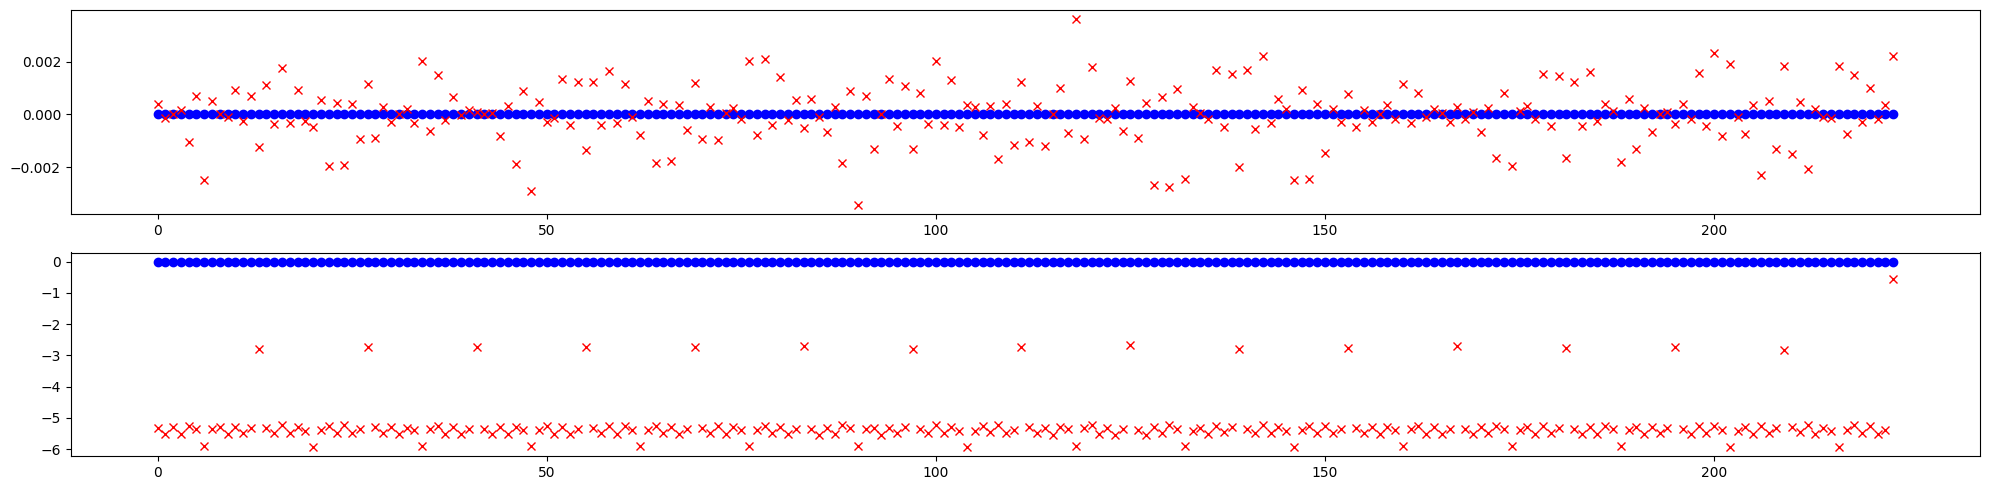

In [169]:
# Compare phase advance

MUX = table.phase_x
MUY = table.phase_y

MUX_SVD = d_x.svd_advance(nux, tbt_x.data)
MUY_SVD = d_y.svd_advance(nuy, tbt_y.data)

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - MUX.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), (mux - MUX_SVD.cpu().numpy()), fmt=' ', marker='x', color='red')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - MUY.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.errorbar(range(model.monitor_count), (muy - MUY_SVD.cpu().numpy()), fmt=' ', marker='x', color='red')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

In [170]:
# Compute parameters

tbt_x.add_noise(noise_x)

time = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

Cxx = 2.0/window.window.sum() * (tbt_x.work * window.window * (2*torch.pi*nux*time).cos()).sum(-1)
Sxx = 2.0/window.window.sum() * (tbt_x.work * window.window * (2*torch.pi*nux*time).sin()).sum(-1)

Axx = (Cxx**2 + Sxx**2).sqrt()
Fxx = torch.atan2(-Sxx, Cxx)

print(torch.allclose(Cxx, +Axx*Fxx.cos()))
print(torch.allclose(Sxx, -Axx*Fxx.sin()))

True
True


tensor(0.1000, dtype=torch.float64)
tensor(0.1000, dtype=torch.float64)


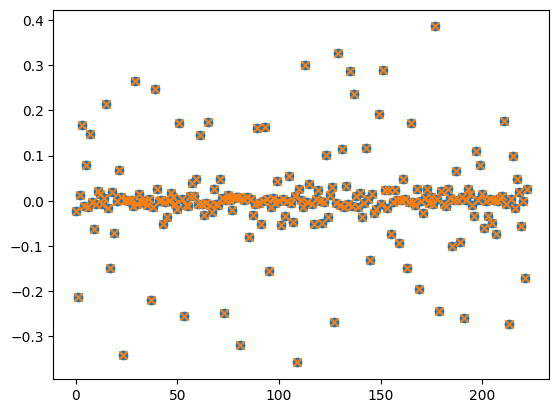

In [171]:
# cot

Mxx = mod(Fxx.diff(), 2*torch.pi)


res_a = 1/MUX.tan()[:-1]
res_b = 1/Mxx.tan()
res_c = ((Cxx.roll(-1)*Cxx + Sxx.roll(-1)*Sxx)/(Cxx.roll(-1)*Sxx - Sxx.roll(-1)*Cxx))[:-1]


plt.scatter(range(model.monitor_count - 1), res_b - res_a)
plt.scatter(range(model.monitor_count - 1), res_c - res_a, marker='x')

from harmonica.statistics import root_mean_square

print(root_mean_square(res_b - res_a))
print(root_mean_square(res_c - res_a))

In [ ]:
# Compare accuracy

cxx = +axx*fxx.cos()
sxx = -axx*fxx.sin()

torch.atan2(-sxx, cxx) - fxx

In [ ]:
# q(i) = c(i) cos(2 pi nu t) + s(i) sin(2 pi nu t) = a(i) cos(2 pi nu t + b(i))

# a(i) = sqrt(c(i)^2 + s(i)^2)
# b(i) = atan2(-s(i), c(i))

# c(i) = +a(i) cos(b(i))
# s(i) = -a(i) sin(b(i))

# cot(B(j) - B(i)) = (a(i) a(j) + b(i) b(j))/(a(j) b(i) - a(i) b(j))
# sin(B(j) - B(i)) = (a(j) b(i) - a(i) b(j))/(A(i) A(j))
# cos(B(j) - B(i)) = (a(i) a(j) + b(i) b(j))/(A(i) A(j))

In [23]:
1/MUX[0].tan() - (AXX[1]*AXX[0] + BXX[1]*BXX[0])/(BXX[1]*AXX[0] - AXX[1]*BXX[0])

tensor(8.8818e-16, dtype=torch.float64)